<a href="https://colab.research.google.com/github/rishyg20/Alpha-Research---Assignment-2/blob/main/Alpha_Research_Assignment2_Pushkal_Rishabh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alpha Research — Assignment 2
### Team: Pushkal & Rishabh

In [2]:
try:
    from fredapi import Fred
except:
    !pip install fredapi
    from fredapi import Fred
try:
    import contexttimer
except:
    !pip install contexttimer
    import contexttimer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
from datetime import datetime, timedelta
import time
import os
import requests

  Preparing metadata (setup.py) ... done
  Created wheel for contexttimer: filename=contexttimer-0.3.3-py3-none-any.whl size=5802 sha256=ee120ab3c387321e24eeccdf03e9473039fff7ca1384561e3c23579cda216578
  Stored in directory: /root/.cache/pip/wheels/45/36/a8/dd6e40dc57caa08493661ba415956ca660c417424d8f487ab6
Successfully built contexttimer


## Section 2: S&P 500 Constituents

In [3]:
start = time.time()
header = {'User-Agent': 'Chrome'}
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers= header)
tables = pd.read_html(response.text)
sp500 = tables[0]

today = datetime.today().strftime("%Y-%m-%d")
sp500['download_date'] = today
print(sp500.shape)
print(sp500.head())
display(sp500)
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

/tmp/ipykernel_674/669635921.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


(503, 9)
  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded download_date  
0    66740         1902    2026-05-20  
1    91142         1916    2026-05-20  
2     1800         1888    2026-05-20  
3  1551152  2013 (1888)    2026-05-20  
4  

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded,download_date
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902,2026-05-20
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916,2026-05-20
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888,2026-05-20
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888),2026-05-20
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989,2026-05-20
...,...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011,2026-05-20
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997,2026-05-20
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969,2026-05-20
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927,2026-05-20


Time taken: 0.33 seconds


In [4]:
start = time.time()

stock_list = sp500['Symbol'].tolist()
end_date = datetime.today().strftime("%Y-%m-%d")
start_date = "2016-01-01"
#downloading Adj Stock price of SP500 constituents
prices = yf.download(stock_list, start = start_date, end = end_date, auto_adjust = True)
display(prices)
print(prices.shape)


end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")
#yfinance drops Adj Close when auto_adjust=True — adjusted prices are stored under Close instead.

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2016-01-01 -> 2026-05-20)')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


Price      Adj Close             Close                                      \
Ticker          BF.B BRK.B           A        AAPL        ABBV        ABNB   
Date                                                                         
2016-01-04       NaN   NaN   37.483688   23.709101   37.397285         NaN   
2016-01-05       NaN   NaN   37.354748   23.114971   37.241478         NaN   
2016-01-06       NaN   NaN   37.520531   22.662611   37.247978         NaN   
2016-01-07       NaN   NaN   35.926861   21.706148   37.137608         NaN   
2016-01-08       NaN   NaN   35.549168   21.820921   36.124962         NaN   
...              ...   ...         ...         ...         ...         ...   
2026-05-13       NaN   NaN  112.739998  298.869995  208.500000  132.970001   
2026-05-14       NaN   NaN  113.260002  298.209991  210.770004  133.669998   
2026-05-15       NaN   NaN  111.699997  300.230011  210.389999  132.850006   
2026-05-18       NaN   NaN  112.110001  297.839996  209.410004  134.300003   
2026-05-19       NaN   NaN  110.570000  298.970001  213.759995  131.160004   

Price                                                     ...   Volume  \
Ticker            ABT       ACGL         ACN        ADBE  ...       WY   
Date                                                      ...            
2016-01-04  35.159637  21.823122   86.213058   91.970001  ...  3556800   
2016-01-05  35.151459  21.902363   86.661774   92.339996  ...  2722800   
2016-01-06  34.856606  21.937229   86.492462   91.019997  ...  4843200   
2016-01-07  34.021229  21.915041   83.952553   89.110001  ...  4917400   
2016-01-08  33.308701  21.686827   83.139771   87.849998  ...  5022600   
...               ...        ...         ...         ...  ...      ...   
2026-05-13  83.830002  93.320000  159.639999  236.070007  ...  7638700   
2026-05-14  84.900002  93.459999  163.990005  237.009995  ...  4360100   
2026-05-15  84.470001  93.980003  168.820007  247.600006  ...  6414400   
2026-05-18  87.910004  95.870003  177.550003  255.639999  ...  4714800   
2026-05-19  88.820000  96.389999  176.800003  254.990005  ...  5812800   

Price                                                                        \
Ticker         WYNN      XEL       XOM      XYL      XYZ       YUM      ZBH   
Date                                                                          
2016-01-04  4249800  2819300  20400100  1353400  2751500   4821623  2104084   
2016-01-05  4286100  2141200  11993500  1075400  2352800   5273420  2294737   
2016-01-06  3316100  5191900  18826900  1866000  1850600   5049330  2751233   
2016-01-07  5525600  5212200  21263800  1555400  1636000  11005453  1829589   
2016-01-08  5740000  3005400  19033600  1471500   587300   5996184  1670969   
...             ...      ...       ...      ...      ...       ...      ...   
2026-05-13  1555100  3867900  15772800  1987300  6467700   1701000  2239200   
2026-05-14  2040700  4269500  11331500  1961000  5270800   1507100  2170800   
2026-05-15  1028100  4702200  27882400  2303900  5109300   2156600  2578900   
2026-05-18  1341000  4971700  20065200  2342400  4806000   1418300  2303200   
2026-05-19  1002200  3642800  20706800  1794300  5721900   1625300  2918400   

Price                          
Ticker         ZBRA       ZTS  
Date                           
2016-01-04   656200   2871700  
2016-01-05   611300   3116700  
2016-01-06   881900   4670500  
2016-01-07  1210600   4324400  
2016-01-08  1034700   4946100  
...             ...       ...  
2026-05-13  1392500  13085600  
2026-05-14  1264600   8714800  
2026-05-15  1224600   8952000  
2026-05-18  1067700   8848300  
2026-05-19  1096000   7292700  

[2609 rows x 2517 columns]

(2609, 2517)
Time taken: 161.59 seconds


In [5]:
start = time.time()
adj_close = prices['Close']
print(adj_close.shape)
print(adj_close.head())
adj_close.to_csv("DATA_PATH" + f"prices_close{today}.csv")
print(f"File saved for {adj_close.shape[1]} stocks, {adj_close.shape[0]} trading days")

end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

(2609, 503)
Ticker              A       AAPL       ABBV  ABNB        ABT       ACGL  \
Date                                                                      
2016-01-04  37.483688  23.709101  37.397285   NaN  35.159637  21.823122   
2016-01-05  37.354748  23.114971  37.241478   NaN  35.151459  21.902363   
2016-01-06  37.520531  22.662611  37.247978   NaN  34.856606  21.937229   
2016-01-07  35.926861  21.706148  37.137608   NaN  34.021229  21.915041   
2016-01-08  35.549168  21.820921  36.124962   NaN  33.308701  21.686827   

Ticker            ACN       ADBE        ADI        ADM  ...         WY  \
Date                                                    ...              
2016-01-04  86.213058  91.970001  44.534790  26.397758  ...  20.020790   
2016-01-05  86.661774  92.339996  44.207573  26.692368  ...  20.067772   
2016-01-06  86.492462  91.019997  42.326050  26.044210  ...  19.624805   
2016-01-07  83.952553  89.110001  41.246231  25.425514  ...  18.899946   
2016-01-08  83.139

In [6]:
#converting stock prices to monthly returns
start = time.time()
monthly_prices = adj_close.resample('ME').last()
monthly_returns = monthly_prices.pct_change()
print(monthly_returns.head())
print(monthly_returns.shape)
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

Ticker             A      AAPL      ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                           
2016-01-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-02-29 -0.007968 -0.001288 -0.005282   NaN  0.023514  0.005774 -0.050028   
2016-03-31  0.066934  0.127211  0.045963   NaN  0.079763  0.046512  0.151007   
2016-04-30  0.029823 -0.139921  0.078189   NaN -0.064365 -0.008579 -0.011989   
2016-05-31  0.121456  0.071773  0.031639   NaN  0.018766  0.030784  0.053578   

Ticker          ADBE       ADI       ADM  ...        WY      WYNN       XEL  \
Date                                      ...                                 
2016-01-31       NaN       NaN       NaN  ...       NaN       NaN       NaN   
2016-02-29 -0.044654 -0.008057 -0.002009  ...  0.014447  0.232686  0.034537   
2016-03-31  0.101585  0.117004  0.038616  ...  0.206172  0.132759  0.066564   
2016-04-30  0.004478 -0.048488  0.099972  ..

/tmp/ipykernel_674/490572405.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_returns = monthly_prices.pct_change()


In [7]:
#Feature creation - Momentum & Volatility

start = time.time()

momentum = monthly_returns.shift(1).rolling(window=11).sum()
print(momentum.shape)
print(momentum.head(15))
#Feature 2 : Volatility
volatility = monthly_returns.rolling(window = 12).std()
print(volatility.shape)

vix = yf.download("^VIX", start = start_date, end = end_date, auto_adjust = True)['Close']
vix_m = vix.resample("ME").last()
print(vix_m.shape)
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

(125, 503)
Ticker             A      AAPL      ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                           
2016-01-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-02-29       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-03-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-04-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-05-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-06-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-07-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-08-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-09-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-10-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2016-11-30       NaN       Na

[*********************100%***********************]  1 of 1 completed

(125, 1)
Time taken: 0.62 seconds


In [10]:
# PIT FRED Data by combing through old releases from ALFRED

from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

timer = contexttimer.timer()
us_business_day = CustomBusinessDay(calendar=USFederalHolidayCalendar())

fred = Fred(api_key = 'ac02c5e5db97deb2a98467f66618c44d')

SERIES = {
    'DGS3MO'      : '3 Month Treasury Yield',
    'T10Y2Y'      : 'Yield Curve 10yr-2yr',
    'DTWEXBGS'    : 'Trade Weighted Dollar Index',
    'DCOILWTICO'  : 'WTI Crude Oil Price',
    'BAMLH0A0HYM2': 'Credit Spread',
    'UNRATE'      : 'Unemployment Rate',
    'CPIAUCSL'    : 'Inflation CPI',
    'GDPC1'       : 'Real GDP',
    'M2SL'        : 'M2 Money Supply',
    'PCECC96'     : 'Real Personal Consumption',
}

START_DATE = '2020-01-01'
est_today = '2026-05-19'

@timer
def releases():
    data = []
    for s in SERIES:
        print(f"Downloading releases for series {s}")
        realtime_start = (pd.to_datetime(START_DATE) - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
        r = fred.get_series_all_releases(s, realtime_start=realtime_start, realtime_end=est_today)
        r = r[r['value'].notna()]
        r['id'] = s
        data.append(r)
    df = pd.concat(data).set_index('id')
    df.date = pd.to_datetime(df.date)
    df.realtime_start = pd.to_datetime(df.realtime_start)
    return df

@timer
def point_in_time(releases_data, end_date = est_today):
    df = pd.DataFrame(index=pd.date_range(START_DATE, end_date, freq=us_business_day))
    df.index.name = 'target_date'
    for s in SERIES:
        print(f"Processing series {s}")
        r = releases_data.loc[s].copy().reset_index()
        r = r.sort_values(['realtime_start', 'date'])

        # only need latest date value published
        # - if the date is pulished for the first time only need it
        # - if only revisions are published only need the latest date value revision
        r = r.drop_duplicates(subset=['realtime_start'], keep='last')

        # carry forward to use the latest data value
        merged = pd.merge_asof(
            pd.DataFrame({'target_date': df.index}),
            r[['realtime_start', 'value', 'date']],
            left_on='target_date',
            right_on='realtime_start',
            direction='backward'
        )
        df[s] = merged['value'].values
        df[f'{s}_pub_date'] = merged['realtime_start'].values
        df[f'{s}_ref_date'] = merged['date'].values
    return df

fred_releases = releases()
fred_pit = point_in_time(releases_data=fred_releases)
fred_pit = fred_pit[list(SERIES.keys())]

#Resampling to monthly

fred_monthly = fred_pit.resample("ME").last().ffill()

print(f"\nFRED data shape: {fred_monthly.shape}")
display(fred_monthly.head(10))
print(fred_monthly.isnull().sum())
fred_monthly= fred_monthly.drop(columns = ['BAMLH0A0HYM2']) #dropping credit spread data since 88 missing values
print(fred_monthly.isnull().sum())
print(f"\nFRED data shape: {fred_monthly.shape}")
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

function releases execution time: 24.679 
Processing series DGS3MO
Processing series T10Y2Y
Processing series DTWEXBGS
Processing series DCOILWTICO
Processing series BAMLH0A0HYM2
Processing series UNRATE
Processing series CPIAUCSL
Processing series GDPC1
Processing series M2SL
Processing series PCECC96
function point_in_time execution time: 0.147 

FRED data shape: (77, 10)


/tmp/ipykernel_674/1452241567.py:75: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fred_monthly = fred_pit.resample("ME").last().ffill()


,DGS3MO,T10Y2Y,DTWEXBGS,DCOILWTICO,BAMLH0A0HYM2,UNRATE,CPIAUCSL,GDPC1,M2SL,PCECC96
target_date,,,,,,,,,,
2020-01-31,1.57,0.18,115.6041,53.09,NaN,3.5,258.501,19219.767,15318.3,13411.938
2020-02-29,1.45,0.27,117.0919,51.36,NaN,3.6,258.820,19220.490,15438.7,13410.416
2020-03-31,0.12,0.47,122.7064,19.48,NaN,3.5,259.050,19221.970,15535.9,13413.811
2020-04-30,0.10,0.44,124.5055,12.17,NaN,4.4,257.953,18987.877,15417.8,13153.000
2020-05-31,0.15,0.49,122.6609,34.70,NaN,14.7,255.902,18974.702,17177.0,13180.837
2020-06-30,0.14,0.50,120.9230,40.60,NaN,13.3,255.768,18977.363,18044.1,13178.952
2020-07-31,0.09,0.44,118.5106,41.46,NaN,11.1,257.214,17205.822,18166.8,11796.645
2020-08-31,0.10,0.58,116.3198,42.44,NaN,10.2,258.723,17282.188,18166.6,11819.579
2020-09-30,0.09,0.56,118.2650,40.47,NaN,8.4,259.681,17302.511,18326.9,11860.250


DGS3MO           0
T10Y2Y           0
DTWEXBGS         0
DCOILWTICO       0
BAMLH0A0HYM2    40
UNRATE           0
CPIAUCSL         0
GDPC1            0
M2SL             0
PCECC96          0
dtype: int64
DGS3MO        0
T10Y2Y        0
DTWEXBGS      0
DCOILWTICO    0
UNRATE        0
CPIAUCSL      0
GDPC1         0
M2SL          0
PCECC96       0
dtype: int64

FRED data shape: (77, 9)
Time taken: 212.4 seconds


In [ ]:
# DATA QUALITY OBSERVATIONS - FRED Macro Data
# =============================================

# DGS3MO (3M Treasury): 2706 daily obs → resampled to 125 monthly
# T10Y2Y (Yield Curve): 2707 daily obs → resampled to 125 monthly
# DTWEXBGS (Dollar Index): 2706 daily obs → resampled to 125 monthly
# DCOILWTICO (WTI Oil): 2702 daily obs → resampled to 125 monthly

# BAMLH0A0HYM2 (Credit Spread): 88 missing values at start of period
# → Series begins after 2016-01-01, shorter history than other series
# → Will handle with dropna() or ffill() during join

# UNRATE, CPIAUCSL, M2SL: Monthly frequency, 124 obs
# GDPC1, PCECC96: Quarterly frequency, only 41 obs
# → Forward filled to monthly using .ffill()

# OVERALL: 125 rows x 10 columns after resampling
# Matches monthly_returns shape (125 x 503) - ready for joining

In [27]:
# FRED release data changes
fred_releases

print('Changes in FRED series releases from 2026-05-15 to 2026-05-19')
dates = pd.date_range('2026-05-15', '2026-05-19')
g = fred_releases[fred_releases.realtime_start.isin(dates)].groupby(['id', 'date']).count()
display(g[g.value > 1])

print('\n\nChange example:')
display(fred_releases.loc[(fred_releases.index == 'PCECC96') & (fred_releases.date == '2025-07-01')])

Changes in FRED series releases from 2026-05-15 to 2026-05-19


,,realtime_start,value
id,date,,




Change example:


,realtime_start,date,value
id,,,
PCECC96,2025-12-23,2025-07-01,16589.126
PCECC96,2026-01-22,2025-07-01,16585.878


In [ ]:
## Section 6: Point-in-Time Analysis

start = time.time()

base_url = 'https://raw.githubusercontent.com/rishyg20/Alpha-Research---Assignment-2/main/fred/'

# Load first and last snapshot
day1 = pd.read_csv(base_url + 'fred_point_in_time_2026-05-15.csv',
                   index_col=0, parse_dates=True)
day5 = pd.read_csv(base_url + 'fred_point_in_time_2026-05-18.csv',
                   index_col=0, parse_dates=True)

# Keep only data columns, drop metadata date columns
data_cols = [c for c in day1.columns if not c.endswith('_date')]
day1_data = day1[data_cols]
day5_data = day5[data_cols]

# Align on common dates and columns
day1_aligned, day5_aligned = day1_data.align(day5_data, join='inner')

# CORRECT comparison - fillna(0) to avoid NaN != NaN false positives
diff_counts = (day1_aligned.fillna(0) != day5_aligned.fillna(0)).sum()
changed_mask = (day1_aligned.fillna(0) != day5_aligned.fillna(0)).any(axis=1)

print(f"Real rows changed: {changed_mask.sum()}")
print(f"\nReal differences per series:")
print(diff_counts[diff_counts > 0] if diff_counts[diff_counts > 0].shape[0] > 0
      else "No real differences found")

# Show the VIX revision example from teammate's releases data
base_url2 = 'https://raw.githubusercontent.com/rishyg20/Alpha-Research---Assignment-2/main/fred/'
releases = pd.read_csv(base_url2 + 'fred_releases.csv', parse_dates=['date', 'realtime_start'])

# Find a good revision example
vix_releases = releases[releases.index == 'VIXCLS'] if 'VIXCLS' in releases.index else releases[releases.get('id', releases.index) == 'VIXCLS']

end = time.time()
print(f"\nTime taken: {round(end-start, 2)} seconds")

Real rows changed: 0

Real differences per series:
No real differences found

Time taken: 1.31 seconds


In [28]:
#Section 4b - Fama French
import zipfile
import io

start = time.time()

#url from Kenneth French Data Library
ff_url = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'

#download and unzip
r = requests.get(ff_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
ff_raw = pd.read_csv(z.open(z.namelist()[0]), skiprows = 3, index_col = 0)

print(ff_raw.head(10))
print(ff_raw.tail(10))
print(ff_raw.index[:5].tolist())

#Keeping monthly values only
def is_valid_month(val):
  try:
    v = int(str(val).strip())
    return 190000 <= v <= 210000
  except:
    return False

ff_monthly = ff_raw[ff_raw.index.map(is_valid_month)].copy()
print(ff_monthly.index[:10].tolist())  # show first 10 index values
print(type(ff_monthly.index[0]))       # show what type they are
ff_monthly.index = pd.to_datetime(ff_monthly.index.astype(str), format = "%Y%m")
ff_monthly.index = ff_monthly.index + pd.offsets.MonthEnd(0)

ff_monthly = ff_monthly.apply(pd.to_numeric, errors = 'coerce')/100

ff_monthly = ff_monthly[start_date:end_date]

print(f"Fama - French shape: {ff_monthly.shape}")
print(f"Columns: {ff_monthly.columns.tolist()}")

display(ff_monthly.head())

end = time.time()



print(f"Time taken: {round(end - start,2)} seconds")



          Mkt-RF       SMB       HML       RMW       CMA        RF
196307     -0.39     -0.48     -0.81      0.64     -1.15      0.27
196308      5.08     -0.80      1.70      0.40     -0.38      0.25
196309     -1.57     -0.43      0.00     -0.78      0.15      0.27
196310      2.54     -1.34     -0.04      2.79     -2.25      0.29
196311     -0.86     -0.85      1.73     -0.43      2.27      0.27
196312      1.83     -1.89     -0.21      0.12     -0.25      0.29
196401      2.27      0.10      1.63      0.21      1.48      0.30
196402      1.55      0.33      2.81      0.11      0.81      0.26
196403      1.41      1.41      3.29     -2.03      2.98      0.31
196404      0.11     -1.48     -0.54     -1.32     -1.13      0.29
                                                      Mkt-RF       SMB  \
  2017                                                 21.51     -6.27   
  2018                                                 -6.83     -5.06   
  2019                                   

,Mkt-RF,SMB,HML,RMW,CMA,RF
2016-01-31,-0.0574,-0.0344,0.0208,0.0278,0.0305,0.0001
2016-02-29,-0.0007,0.0087,-0.0061,0.0331,0.0194,0.0002
2016-03-31,0.0695,0.0100,0.0122,0.0068,0.0001,0.0002
2016-04-30,0.0091,0.0123,0.0322,-0.0285,0.0177,0.0001
2016-05-31,0.0178,-0.0062,-0.0162,-0.0110,-0.0254,0.0001


Time taken: 0.22 seconds


In [39]:
fred_clean.date.min()

Timestamp('2020-01-31 00:00:00')

In [29]:
# Joining the data

start = time.time()

# Stack each wide dataframe into long format
returns_long = monthly_returns.stack().reset_index()
returns_long.columns = ['date', 'ticker', 'return']

momentum_long = momentum.stack().reset_index()
momentum_long.columns = ['date', 'ticker', 'momentum']

volatility_long = volatility.stack().reset_index()
volatility_long.columns = ['date', 'ticker', 'volatility']

# Merge price-based signals
panel = returns_long.merge(momentum_long, on=['date', 'ticker'], how='inner')
panel = panel.merge(volatility_long, on=['date', 'ticker'], how='inner')
print(f"After price signals: {panel.shape}")

# Fix fred_monthly - always reset index cleanly
fred_clean = fred_monthly.copy()
if fred_clean.index.name == 'date' or fred_clean.index.name is not None:
    fred_clean = fred_clean.reset_index()
fred_clean.columns = [c if c != 'index' else 'date' for c in fred_clean.columns]
fred_clean = fred_clean[[c for c in fred_clean.columns if c not in ['level_0', 'level_1']]]

# Fix ff_monthly - same approach
ff_clean = ff_monthly.copy()
if ff_clean.index.name == 'date' or ff_clean.index.name is not None:
    ff_clean = ff_clean.reset_index()
ff_clean.columns = [c if c != 'index' else 'date' for c in ff_clean.columns]
ff_clean = ff_clean[[c for c in ff_clean.columns if c not in ['level_0', 'level_1']]]

print(fred_clean.columns.tolist())
print(ff_clean.columns.tolist())

print("fred_clean columns:", fred_clean.columns.tolist())
print("fred_clean index name:", fred_clean.index.name)
print("fred_clean head:")
print(fred_clean.head(2))

print("panel columns:", panel.columns.tolist())
print("panel index name:", panel.index.name)

fred_clean = fred_monthly.copy().reset_index()
fred_clean.columns = ['date'] + [c for c in fred_clean.columns[1:]]

ff_clean = ff_monthly.copy().reset_index()
ff_clean.columns = ['date'] + [c for c in ff_clean.columns[1:]]

print(fred_clean.columns.tolist())
print(fred_clean.head(2))

# Merge macro data
panel = panel.merge(a
                    , on='date', how='left')
panel = panel.merge(ff_clean, on='date', how='left')

vix_df = vix_m.reset_index()
vix_df.columns = ['date', 'VIX']
panel = panel.merge(vix_df, on='date', how='left')

print(f"Final panel: {panel.shape}")
display(panel.head())

end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

After price signals: (54879, 5)
['target_date', 'DGS3MO', 'T10Y2Y', 'DTWEXBGS', 'DCOILWTICO', 'UNRATE', 'CPIAUCSL', 'GDPC1', 'M2SL', 'PCECC96']
['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
fred_clean columns: ['target_date', 'DGS3MO', 'T10Y2Y', 'DTWEXBGS', 'DCOILWTICO', 'UNRATE', 'CPIAUCSL', 'GDPC1', 'M2SL', 'PCECC96']
fred_clean index name: None
fred_clean head:
  target_date  DGS3MO  T10Y2Y  DTWEXBGS  DCOILWTICO  UNRATE  CPIAUCSL  \
0  2020-01-31    1.57    0.18  115.6041       53.09     3.5   258.501   
1  2020-02-29    1.45    0.27  117.0919       51.36     3.6   258.820   

       GDPC1     M2SL    PCECC96  
0  19219.767  15318.3  13411.938  
1  19220.490  15438.7  13410.416  
panel columns: ['date', 'ticker', 'return', 'momentum', 'volatility']
panel index name: None
['date', 'DGS3MO', 'T10Y2Y', 'DTWEXBGS', 'DCOILWTICO', 'UNRATE', 'CPIAUCSL', 'GDPC1', 'M2SL', 'PCECC96']
        date  DGS3MO  T10Y2Y  DTWEXBGS  DCOILWTICO  UNRATE  CPIAUCSL  \
0 2020-01-31    1.57    0.18  115.6041 

,date,ticker,return,momentum,volatility,DGS3MO,T10Y2Y,DTWEXBGS,DCOILWTICO,UNRATE,...,GDPC1,M2SL,PCECC96,Mkt-RF,SMB,HML,RMW,CMA,RF,VIX
0,2017-01-31,A,0.074846,0.218915,0.055968,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0194,-0.0144,-0.0276,-0.0051,-0.0106,0.0004,11.99
1,2017-01-31,AAPL,0.047747,0.225022,0.070427,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0194,-0.0144,-0.0276,-0.0051,-0.0106,0.0004,11.99
2,2017-01-31,ABBV,-0.014267,0.177739,0.056882,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0194,-0.0144,-0.0276,-0.0051,-0.0106,0.0004,11.99
3,2017-01-31,ABT,0.094502,0.053315,0.066635,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0194,-0.0144,-0.0276,-0.0051,-0.0106,0.0004,11.99
4,2017-01-31,ACGL,0.023873,0.255619,0.039078,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0194,-0.0144,-0.0276,-0.0051,-0.0106,0.0004,11.99


Time taken: 0.12 seconds


In [30]:
start = time.time()

print(panel.dtypes)
print(panel.isnull().sum())
panel = panel.dropna(subset = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF'])
print(panel.dtypes)
print(panel.isnull().sum())
print(panel.shape)

#Adding derived macro factors
panel['CPI_change'] = panel.groupby('ticker')['CPIAUCSL'].pct_change()
panel['GDP_growth'] = panel.groupby('ticker')['GDPC1'].pct_change()
panel['Oil_change'] = panel.groupby('ticker')['DCOILWTICO'].pct_change()

panel = panel.dropna(subset = ['CPI_change', 'GDP_growth', 'Oil_change'])
print(panel.isnull().sum())
print(panel.shape)

end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")




date          datetime64[ns]
ticker                object
return               float64
momentum             float64
volatility           float64
DGS3MO               float64
T10Y2Y               float64
DTWEXBGS             float64
DCOILWTICO           float64
UNRATE               float64
CPIAUCSL             float64
GDPC1                float64
M2SL                 float64
PCECC96              float64
Mkt-RF               float64
SMB                  float64
HML                  float64
RMW                  float64
CMA                  float64
RF                   float64
VIX                  float64
dtype: object
date              0
ticker            0
return            0
momentum          0
volatility        0
DGS3MO        16998
T10Y2Y        16998
DTWEXBGS      16998
DCOILWTICO    16998
UNRATE        16998
CPIAUCSL      16998
GDPC1         16998
M2SL          16998
PCECC96       16998
Mkt-RF         1000
SMB            1000
HML            1000
RMW            1000
CMA            10

/tmp/ipykernel_674/1024956725.py:11: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  panel['CPI_change'] = panel.groupby('ticker')['CPIAUCSL'].pct_change()
/tmp/ipykernel_674/1024956725.py:12: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  panel['GDP_growth'] = panel.groupby('ticker')['GDPC1'].pct_change()
/tmp/ipykernel_674/1024956725.py:13: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill N

In [37]:

panel.date.min()

Timestamp('2020-02-29 00:00:00')

In [31]:
#Forward return - predictand

if 'forward_return' not in panel.columns:
    panel['forward_return'] = panel.groupby('ticker')['return'].shift(-1)
    panel = panel.dropna(subset=['forward_return'])
print(panel.shape)


# Define X and Y
y = panel['forward_return']

X_cols = [
    'momentum',
    'VIX',
    'volatility',
    'DGS3MO',
    'T10Y2Y',
    'Mkt-RF',
    'SMB',
    'HML',
    'RMW',
    'CMA',
    'CPI_change',
    'GDP_growth',
    'Oil_change'
]

X = panel[X_cols]

X = sm.add_constant(X)

print(X.shape)
print(y.shape)

model = sm.OLS(y, X)

results = model.fit()

print(results.summary())

(35881, 25)
(35881, 14)
(35881,)
                            OLS Regression Results                            
Dep. Variable:         forward_return   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     159.6
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        18:26:31   Log-Likelihood:                 32875.
No. Observations:               35881   AIC:                        -6.572e+04
Df Residuals:                   35867   BIC:                        -6.560e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.10

R-squared: 0.0547
Adjusted R-squared: 0.0544
F-statistic p-value: 0.000000
Number of observations: 35881


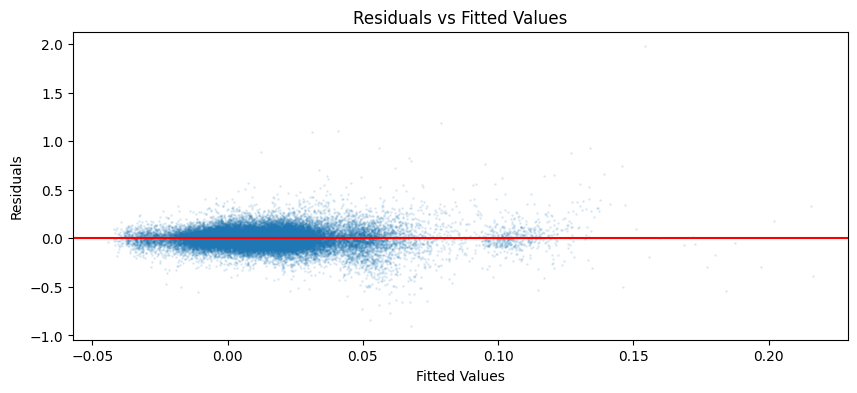

In [32]:
# Key results summary
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"F-statistic p-value: {results.f_pvalue:.6f}")
print(f"Number of observations: {results.nobs:.0f}")

# Plot actual vs predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.scatter(results.fittedvalues, results.resid, alpha=0.1, s=1)
plt.axhline(0, color='red')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif['feature'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
vif

,feature,VIF
0,const,98.846481
1,momentum,1.201503
2,VIX,3.802619
3,volatility,1.097184
4,DGS3MO,6.517597
5,T10Y2Y,3.271485
6,Mkt-RF,2.098258
7,SMB,1.928172
8,HML,2.714186
9,RMW,1.438816


In [34]:
# winsor
for c in [
    'DGS3MO',
    'T10Y2Y',
    'Mkt-RF',
    'SMB',
    'HML',
    'RMW',
    'CMA',
    'CPI_change',
    'GDP_growth',
    'Oil_change'
]:
  X[c] = X[c].clip(X[c].quantile(.01), X[c].quantile(.99))

In [35]:
model = sm.OLS(y, X)

results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:         forward_return   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     159.6
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        18:27:22   Log-Likelihood:                 32875.
No. Observations:               35881   AIC:                        -6.572e+04
Df Residuals:                   35867   BIC:                        -6.560e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1042      0.005    -20.498      0.0